In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.neighbors import KNeighborsRegressor

RANDOM_STATE = 42

# 1. Load Model & Preprocessing

In [23]:
file_path = 'ae_only_unambiguous_1000.csv'
df = pd.read_csv(file_path, encoding='utf-8', encoding_errors='ignore', dtype={'lang5.x': str, 'lang6.x': str})

## 1.1 Agregasi Rata-Rata Skor Berdasarkan Gambar

In [24]:
df_target = df.groupby('website')['response.x'].mean().reset_index()

df_target = df_target.rename(columns={
    'website': 'image_name',
    'response.x': 'skor_estetika'
})

df_target['image_name'] = df_target['image_name'] + '.png'
df_target.head(5)

,image_name,skor_estetika
0,english_0.png,2.290287
1,english_1.png,4.195294
2,english_10.png,3.926130
3,english_100.png,4.958242
4,english_101.png,4.864776


In [25]:
df_target.shape

(418, 2)

In [26]:
df_cnn = pd.read_csv('ekstrak_cnn.csv')
df_cv = pd.read_csv('ekstrak_matematika_opencv.csv')

df_hybrid = pd.merge(df_cnn, df_cv, on='image_name', how='inner')
df_hybrid.head(5)

,image_name,cnn_feat_0,cnn_feat_1,cnn_feat_2,cnn_feat_3,cnn_feat_4,cnn_feat_5,cnn_feat_6,cnn_feat_7,cnn_feat_8,...,purple,fuchsia,green,lime,olive,yellow,navy,blue,teal,aqua
0,english_0.png,-4.721025,2.358559,-3.684831,0.463756,-0.524554,1.350653,-0.075894,1.700438,0.542055,...,0.000000,0.000000,0.000544,0.000000,0.000547,0.000252,0.019568,0.000340,0.005155,0.001189
1,english_1.png,1.210117,5.665122,-3.581102,-1.811846,-4.932022,0.047140,-0.264386,1.231203,0.168720,...,0.000048,0.000160,0.000078,0.000011,0.002449,0.002518,0.001640,0.000699,0.075212,0.003403
2,english_10.png,-2.391359,3.296005,0.787008,0.606368,0.721851,0.919729,0.678484,-0.327567,-0.328909,...,0.007382,0.000051,0.000003,0.000000,0.001636,0.001023,0.009420,0.000594,0.015256,0.006435
3,english_100.png,-0.749734,0.351490,4.590096,2.475029,-1.191490,-3.183770,3.293322,-1.044738,0.705354,...,0.000027,0.000000,0.000000,0.000000,0.085815,0.054267,0.000006,0.000000,0.005960,0.000017
4,english_101.png,4.423751,-1.595877,-1.300480,1.046409,0.702248,3.977708,-0.080589,-2.913515,1.900459,...,0.000015,0.000000,0.021142,0.000000,0.008461,0.000000,0.153999,0.000011,0.057641,0.000156


In [27]:
df_hybrid.shape

(410, 53)

## 1.2 Merge Data Target, Ekstrasi CNN, dan Ekstraksi OpenCV

In [28]:
df_final = pd.merge(df_hybrid, df_target, on='image_name', how='inner')
df_final.head(5)

,image_name,cnn_feat_0,cnn_feat_1,cnn_feat_2,cnn_feat_3,cnn_feat_4,cnn_feat_5,cnn_feat_6,cnn_feat_7,cnn_feat_8,...,fuchsia,green,lime,olive,yellow,navy,blue,teal,aqua,skor_estetika
0,english_0.png,-4.721025,2.358559,-3.684831,0.463756,-0.524554,1.350653,-0.075894,1.700438,0.542055,...,0.000000,0.000544,0.000000,0.000547,0.000252,0.019568,0.000340,0.005155,0.001189,2.290287
1,english_1.png,1.210117,5.665122,-3.581102,-1.811846,-4.932022,0.047140,-0.264386,1.231203,0.168720,...,0.000160,0.000078,0.000011,0.002449,0.002518,0.001640,0.000699,0.075212,0.003403,4.195294
2,english_10.png,-2.391359,3.296005,0.787008,0.606368,0.721851,0.919729,0.678484,-0.327567,-0.328909,...,0.000051,0.000003,0.000000,0.001636,0.001023,0.009420,0.000594,0.015256,0.006435,3.926130
3,english_100.png,-0.749734,0.351490,4.590096,2.475029,-1.191490,-3.183770,3.293322,-1.044738,0.705354,...,0.000000,0.000000,0.000000,0.085815,0.054267,0.000006,0.000000,0.005960,0.000017,4.958242
4,english_101.png,4.423751,-1.595877,-1.300480,1.046409,0.702248,3.977708,-0.080589,-2.913515,1.900459,...,0.000000,0.021142,0.000000,0.008461,0.000000,0.153999,0.000011,0.057641,0.000156,4.864776


In [29]:
df_final.shape

(398, 54)

In [30]:
X_cv = pd.merge(df_cv, df_target, on='image_name', how='inner').drop(columns=['image_name', 'skor_estetika'])
X_cv.shape

(398, 22)

In [31]:
X_cnn = pd.merge(df_cnn, df_target, on='image_name', how='inner').drop(columns=['image_name', 'skor_estetika'])
X_cnn.shape

(398, 30)

## 1.3 Split & Scale Data

In [32]:
X = df_final.drop(columns=['image_name', 'skor_estetika'])
y = df_final['skor_estetika']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Building Model

## 2.1 Linear Regression

### Training dan Prediksi Dasar

In [33]:
lr_model = LinearRegression()

t0 = time.perf_counter()
lr_model.fit(X_train_scaled, y_train)
waktu_train = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred = lr_model.predict(X_test_scaled)
waktu_predict = time.perf_counter() - t0

r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, lr_model.predict(X_train_scaled))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score (test)  : {r2_test:.4f}")
print(f"R2 Score (train) : {r2_train:.4f}")
print(f"RMSE             : {rmse:.4f}")
print(f"Waktu training   : {waktu_train:.4f} detik")
print(f"Waktu prediksi   : {waktu_predict:.4f} detik")


R2 Score (test)  : 0.2715
R2 Score (train) : 0.6507
RMSE             : 0.7861
Waktu training   : 0.0026 detik
Waktu prediksi   : 0.0004 detik


### Model Fine-Tuning

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_lr = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

r2_test = best_lr.predict(X_test_scaled)
r2_train = best_lr.predict(X_train_scaled)
cv_r2 = grid_search.best_score_

print(f"Tuned R2  (test) : {r2_score(y_test, r2_test):.4f}")
print(f"Tuned R2 (train) : {r2_score(y_train, r2_train):.4f}")
print(f"Mean CV R2 (Real Train/Val Baseline): {cv_r2:.4f}")
print(f"Tuned RMSE       : {np.sqrt(mean_squared_error(y_test, r2_test)):.4f}")

Best Parameters: {'fit_intercept': True, 'positive': False}
Tuned R2  (test) : 0.2715
Tuned R2 (train) : 0.6507
Mean CV R2 (Real Train/Val Baseline): -0.0070
Tuned RMSE       : 0.7861


### Training Best-Model


In [35]:
lr_model = LinearRegression(fit_intercept=True, positive=False)

t0 = time.perf_counter()
lr_model.fit(X_train_scaled, y_train)
waktu_train = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred = lr_model.predict(X_test_scaled)
waktu_predict = time.perf_counter() - t0

r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, lr_model.predict(X_train_scaled))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score (test)  : {r2_test:.4f}")
print(f"R2 Score (train) : {r2_train:.4f}")
print(f"RMSE             : {rmse:.4f}")
print(f"Waktu training   : {waktu_train:.4f} detik")
print(f"Waktu prediksi   : {waktu_predict:.4f} detik")

R2 Score (test)  : 0.2715
R2 Score (train) : 0.6507
RMSE             : 0.7861
Waktu training   : 0.0034 detik
Waktu prediksi   : 0.0005 detik


## 2.2 K-Nearest-Neighbours

### Training dan Prediksi Dasar

In [36]:
knn = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='cosine')

t0 = time.perf_counter()
knn.fit(X_train_scaled, y_train)
waktu_train_knn = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_knn = knn.predict(X_test_scaled)
waktu_predict_knn = time.perf_counter() - t0

r2_test = r2_score(y_test, y_pred_knn)
r2_train = r2_score(y_train, knn.predict(X_train_scaled))
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print(f"R2 Score (test)    : {r2_test:.4f}")
print(f"R2 Score (train)   : {r2_train:.4f}")
print(f"RMSE               : {rmse:.4f}")
print(f"Waktu training     : {waktu_train_knn:.4f} detik")
print(f"Waktu prediksi     : {waktu_predict_knn:.4f} detik")

R2 Score (test)    : 0.2878
R2 Score (train)   : 0.5212
RMSE               : 0.7772
Waktu training     : 0.0010 detik
Waktu prediksi     : 0.0023 detik


### Model Fine-Tuning

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [7, 8, 9, 10, 11, 12, 13, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    scoring='r2',
    cv=8,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

r2_test = best_knn.predict(X_test_scaled)
r2_train = best_knn.predict(X_train_scaled)
cv_r2 = grid_search.best_score_

print(f"Tuned R2  (test) : {r2_score(y_test, r2_test):.4f}")
print(f"Tuned R2 (train) : {r2_score(y_train, r2_train):.4f}")
print(f"Mean CV R2 (Real Train/Val Baseline): {cv_r2:.4f}")
print(f"Tuned RMSE       : {np.sqrt(mean_squared_error(y_test, r2_test)):.4f}")

Best Parameters: {'metric': 'cosine', 'n_neighbors': 23, 'weights': 'distance'}
Tuned R2  (test) : 0.3838
Tuned R2 (train) : 1.0000
Mean CV R2 (Real Train/Val Baseline): 0.3466
Tuned RMSE       : 0.7230


### Training Best Model

In [38]:
knn = KNeighborsRegressor(n_neighbors=23, weights='distance', metric='cosine')

t0 = time.perf_counter()
knn.fit(X_train_scaled, y_train)
waktu_train_knn = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_knn = knn.predict(X_test_scaled)
waktu_predict_knn = time.perf_counter() - t0

r2_test = r2_score(y_test, y_pred_knn)
r2_train = r2_score(y_train, knn.predict(X_train_scaled))
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print(f"R2 Score (test)    : {r2_test:.4f}")
print(f"R2 Score (train)   : {r2_train:.4f}")
print(f"RMSE               : {rmse:.4f}")
print(f"Waktu training     : {waktu_train_knn:.4f} detik")
print(f"Waktu prediksi     : {waktu_predict_knn:.4f} detik")

R2 Score (test)    : 0.3838
R2 Score (train)   : 1.0000
RMSE               : 0.7230
Waktu training     : 0.0008 detik
Waktu prediksi     : 0.0017 detik


## 2.3 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=RANDOM_STATE)

t0 = time.perf_counter()
dt_model.fit(X_train_scaled, y_train)
waktu_train_dt = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_dt = dt_model.predict(X_test_scaled)
waktu_predict_dt = time.perf_counter() - t0

r2 = r2_score(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"R2 Score (test)     : {r2:.4f}")
print(f"RMSE            : {rmse:.4f}")
print(f"Waktu training  : {waktu_train_dt:.4f} detik")
print(f"Waktu prediksi  : {waktu_predict_dt:.4f} detik")

r2_train = r2_score(y_train, dt_model.predict(X_train_scaled))
print(f"R2 Score (train) : {r2_train:.4f}")

R2 Score (test)     : 0.2287
RMSE            : 0.7123
Waktu training  : 0.0069 detik
Waktu prediksi  : 0.0006 detik
R2 Score (train) : 0.5773


# 3. Evaluation

## 3.1 Ringkasan Perbandingan Model

Membandingkan ketiga model (Linear Regression, KNN, Decision Tree) yang sudah dilatih sebelumnya menggunakan metrik R2 (train/test), RMSE, dan waktu komputasi.

In [ ]:
hasil_model = {
    'Linear Regression': {
        'model': lr_model,
        'y_pred': lr_model.predict(X_test_scaled),
        'waktu_train': waktu_train,
        'waktu_predict': waktu_predict,
    },
    'KNN (Tuned)': {
        'model': knn,
        'y_pred': y_pred_knn,
        'waktu_train': waktu_train_knn,
        'waktu_predict': waktu_predict_knn,
    },
    'Decision Tree': {
        'model': dt_model,
        'y_pred': y_pred_dt,
        'waktu_train': waktu_train_dt,
        'waktu_predict': waktu_predict_dt,
    },
}

rows = []
for nama, info in hasil_model.items():
    m = info['model']
    y_pred_test = info['y_pred']
    y_pred_train = m.predict(X_train_scaled)
    rows.append({
        'Model': nama,
        'R2 Train': r2_score(y_train, y_pred_train),
        'R2 Test': r2_score(y_test, y_pred_test),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Waktu Train (s)': info['waktu_train'],
        'Waktu Predict (s)': info['waktu_predict'],
    })

df_ringkasan = pd.DataFrame(rows).sort_values('R2 Test', ascending=False).reset_index(drop=True)
df_ringkasan

,Model,R2 Train,R2 Test,RMSE Test,Waktu Train (s),Waktu Predict (s)
0,Linear Regression,0.745537,0.403783,0.626268,0.003814,0.000740
1,KNN (Tuned),1.000000,0.390204,0.633359,0.001863,0.002784
2,Decision Tree,0.577283,0.228708,0.712307,0.006901,0.000604


## 3.2 Check Overfitting

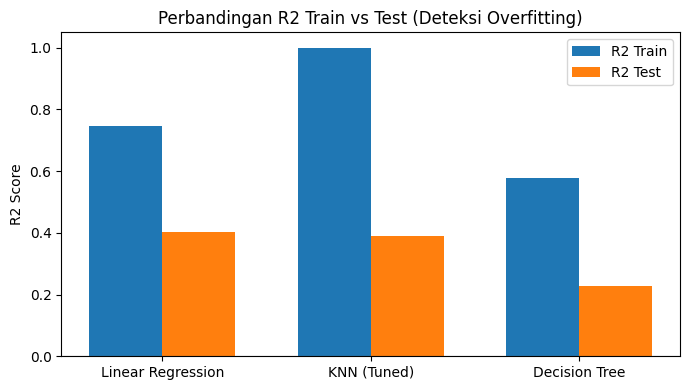

Linear Regression    | Gap Train-Test R2 = 0.3418 -> Overfitting tinggi
KNN (Tuned)          | Gap Train-Test R2 = 0.6098 -> Overfitting tinggi
Decision Tree        | Gap Train-Test R2 = 0.3486 -> Overfitting tinggi


In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(df_ringkasan))
width = 0.35

ax.bar(x - width/2, df_ringkasan['R2 Train'], width, label='R2 Train')
ax.bar(x + width/2, df_ringkasan['R2 Test'], width, label='R2 Test')

ax.set_xticks(x)
ax.set_xticklabels(df_ringkasan['Model'])
ax.set_ylabel('R2 Score')
ax.set_title('Perbandingan R2 Train vs Test (Deteksi Overfitting)')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

gap = df_ringkasan['R2 Train'] - df_ringkasan['R2 Test']
for nama, g in zip(df_ringkasan['Model'], gap):
    status = 'Overfitting tinggi' if g > 0.3 else ('Overfitting ringan' if g > 0.1 else 'Relatif stabil')
    print(f"{nama:20s} | Gap Train-Test R2 = {g:.4f} -> {status}")

## 3.3 Korelasi Fitur CNN dengan Fitur OpenCV (image processing)

In [ ]:
kolom_cnn = [col for col in df_hybrid.columns if 'cnn_feat' in col]
kolom_cv = [col for col in df_hybrid.columns if col not in kolom_cnn and col not in ['image_name', 'skor_estetika']]

matriks_korelasi = df_hybrid[kolom_cnn + kolom_cv].corr()

for i in range(30):
  target_fitur = f'cnn_feat_{str(i)}'
  korelasi_feat_7 = matriks_korelasi.loc[target_fitur, kolom_cv]
  korelasi_feat_7_sorted = korelasi_feat_7.abs().sort_values(ascending=False)

  print("\n======================================================")
  print(f"Korelasi tertinggi untuk {target_fitur} dengan fitur OpenCV:")
  print(korelasi_feat_7.loc[korelasi_feat_7_sorted.index].head())


Korelasi tertinggi untuk cnn_feat_0 dengan fitur OpenCV:
white              -0.535615
quadtree_leaves     0.517448
image_area_ratio    0.411305
colorfulness        0.335544
gray                0.291772
Name: cnn_feat_0, dtype: float64

Korelasi tertinggi untuk cnn_feat_1 dengan fitur OpenCV:
white               0.482866
black              -0.430684
symmetry           -0.345834
maroon             -0.304175
image_area_ratio    0.217094
Name: cnn_feat_1, dtype: float64

Korelasi tertinggi untuk cnn_feat_2 dengan fitur OpenCV:
black     -0.365272
white      0.340232
teal      -0.233975
balance    0.201654
yellow     0.170520
Name: cnn_feat_2, dtype: float64

Korelasi tertinggi untuk cnn_feat_3 dengan fitur OpenCV:
quadtree_leaves    -0.532910
colorfulness       -0.386566
red                -0.323567
image_area_ratio   -0.225984
maroon             -0.208791
Name: cnn_feat_3, dtype: float64

Korelasi tertinggi untuk cnn_feat_4 dengan fitur OpenCV:
black               0.298145
quadtree_leave

## 3.4 Ringkasan Reverse Checking

Selain melihat daftar korelasi per komponen PCA di atas, dibuat juga visualisasi heatmap korelasi antara seluruh fitur CNN dan fitur OpenC, serta ringkasan komponen CNN mana yang paling 'terwakili' oleh fitur OpenCV (image processing).

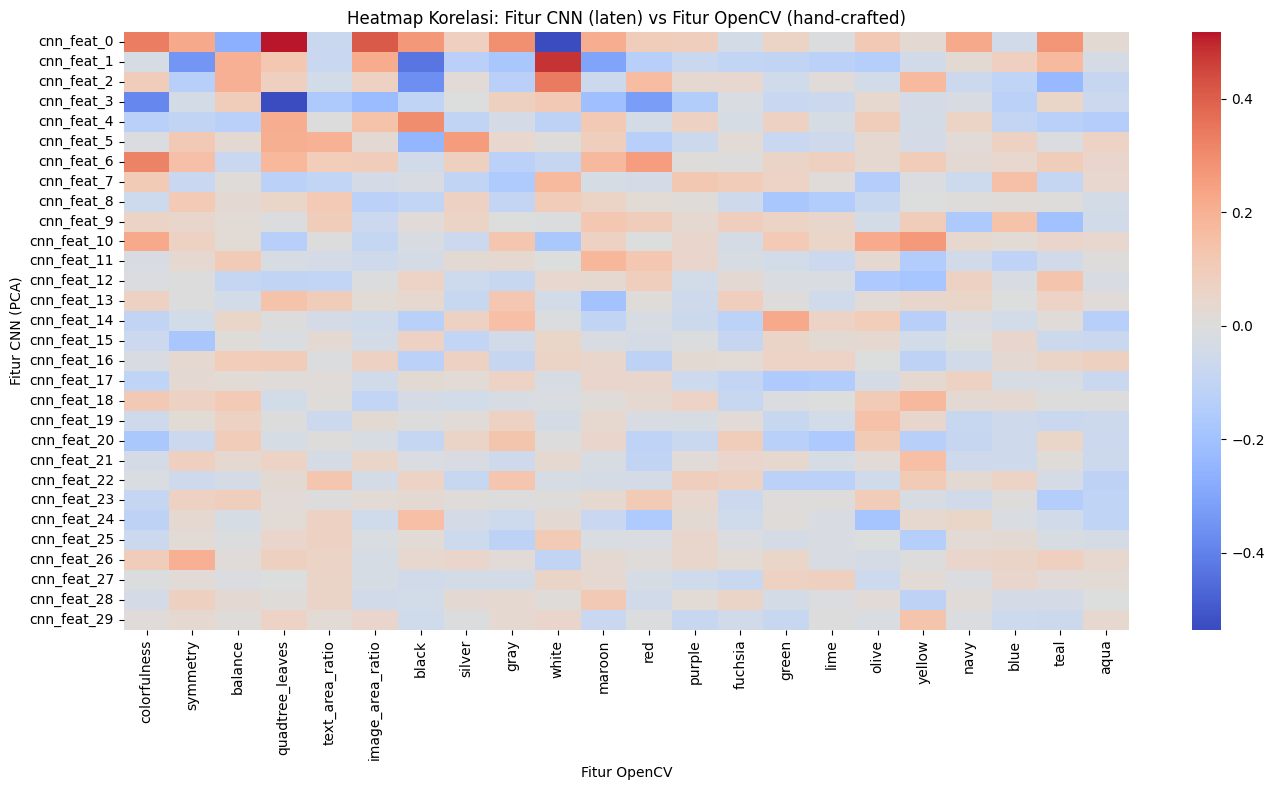

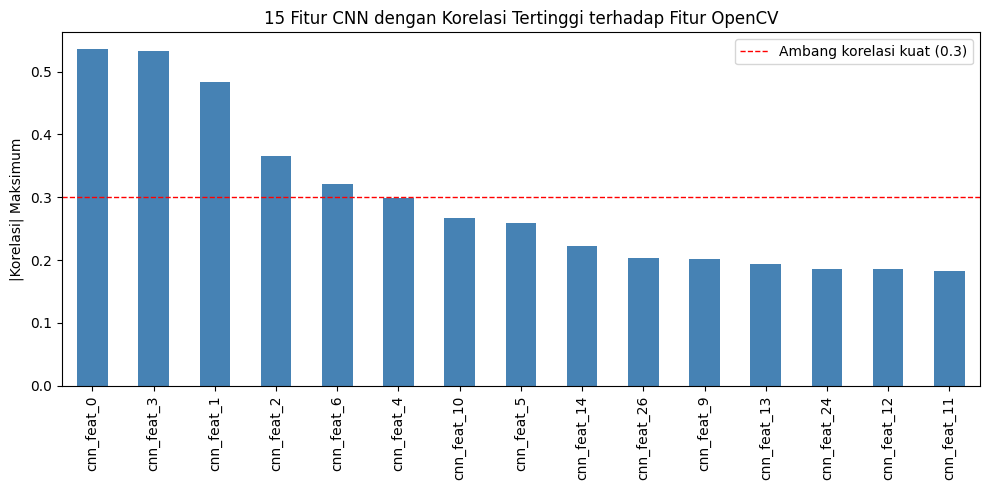

Rata-rata korelasi absolut maksimum antar fitur CNN vs OpenCV: 0.2212
Interpretasi: nilai yang relatif rendah (<0.3) menunjukkan fitur CNN memang menangkap
informasi visual yang berbeda dari fitur OpenCV
arsitektur hybrid (CNN dan OpenCV) tidak sepenuhnya redundan).


In [ ]:
plt.figure(figsize=(14,8))
sns.heatmap(matriks_korelasi.loc[kolom_cnn, kolom_cv], cmap = 'coolwarm', center = 0)
plt.title('Heatmap Korelasi: Fitur CNN (laten) vs Fitur OpenCV (hand-crafted)')
plt.xlabel('Fitur OpenCV')
plt.ylabel('Fitur CNN (PCA)')
plt.tight_layout()
plt.show()

# Korelasi absolut maksimum tiap fitur CNN terhadap fitur OpenCV manapun
maks_korelasi = matriks_korelasi.loc[kolom_cnn, kolom_cv].abs().max(axis=1).sort_values(ascending = False)

plt.figure(figsize=(10,5))
maks_korelasi.head(15).plot(kind = 'bar', color = 'steelblue')
plt.title('15 Fitur CNN dengan Korelasi Tertinggi terhadap Fitur OpenCV')
plt.ylabel('|Korelasi| Maksimum')
plt.axhline(0.3, color = 'red', linestyle = '--', linewidth = 1, label = 'Ambang korelasi kuat (0.3)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rata-rata korelasi absolut maksimum antar fitur CNN vs OpenCV: {maks_korelasi.mean():.4f}")
print("Interpretasi: nilai yang relatif rendah (<0.3) menunjukkan fitur CNN memang menangkap")
print("informasi visual yang berbeda dari fitur OpenCV")
print("arsitektur hybrid (CNN dan OpenCV) tidak sepenuhnya redundan).")

# 4. Result Analysis

Analisis hasil prediksi dari model terbaik (berdasarkan R2 Test tertinggi pada tabel ringkasan di atas), mencakup scatter actual vs predicted, plot residual, dan distribusi error.

Model terbaik: Linear Regression


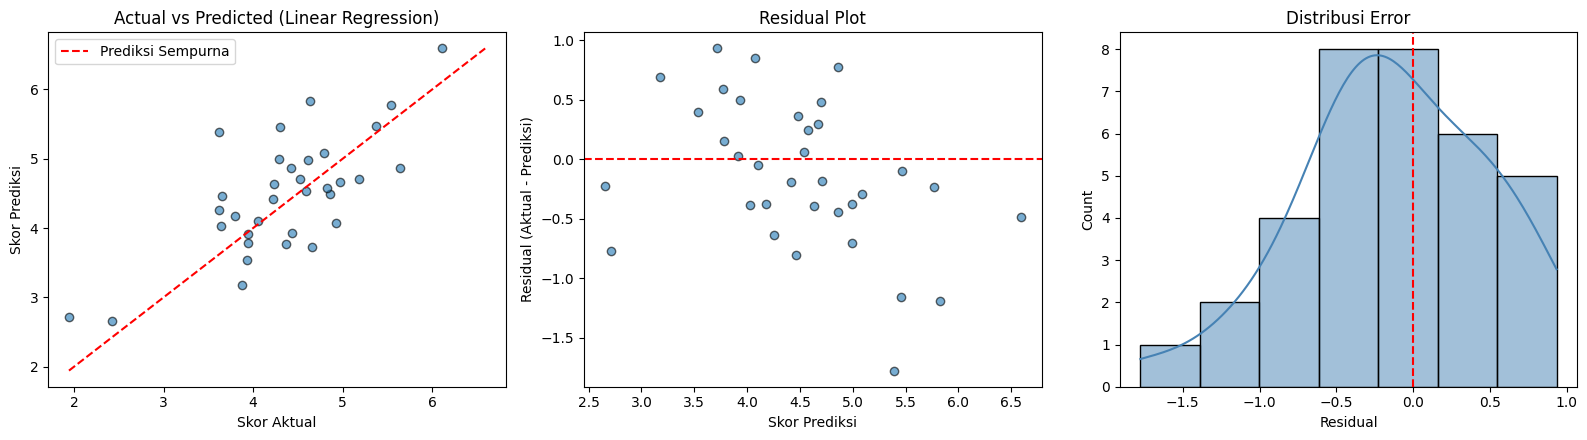

Mean residual : -0.1282 (idealnya mendekati 0)
Std residual  : 0.6130


In [ ]:
nama_model_terbaik = df_ringkasan.iloc[0]['Model']
model_terbaik = hasil_model[nama_model_terbaik]['model']
y_pred_terbaik = hasil_model[nama_model_terbaik]['y_pred']
residual = y_test.values - y_pred_terbaik

print(f"Model terbaik: {nama_model_terbaik}")

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_terbaik, alpha=0.6, edgecolor='k')
lims = [min(y_test.min(), y_pred_terbaik.min()), max(y_test.max(), y_pred_terbaik.max())]
axes[0].plot(lims, lims, 'r--', label='Prediksi Sempurna')
axes[0].set_xlabel('Skor Aktual')
axes[0].set_ylabel('Skor Prediksi')
axes[0].set_title(f'Actual vs Predicted ({nama_model_terbaik})')
axes[0].legend()

# Residual plot
axes[1].scatter(y_pred_terbaik, residual, alpha=0.6, edgecolor='k')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Skor Prediksi')
axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title('Residual Plot')

# Distribusi error
sns.histplot(residual, kde=True, ax=axes[2], color='steelblue')
axes[2].axvline(0, color='r', linestyle='--')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribusi Error')

plt.tight_layout()
plt.show()

print(f"Mean residual : {residual.mean():.4f} (idealnya mendekati 0)")
print(f"Std residual  : {residual.std():.4f}")

# 5. Eksperimen Tambahan

## 5.1 CNN-only vs OpenCV-only vs Hybrid

**Tujuan:** Membuktikan secara empiris klaim arsitektur bahwa penggabungan fitur CNN + OpenCV (hybrid) memberikan hasil lebih baik dibanding menggunakan salah satu cabang saja. Model yang dipakai untuk perbandingan adalah KNN dengan konfigurasi terbaik yang sudah ditemukan sebelumnya, dilatih ulang pada tiga skema fitur berbeda.

In [ ]:
skema_fitur = {
    'CNN-only': X_cnn,
    'OpenCV-only': X_cv,
    'Hybrid': X,
}

hasil_ablasi = []
for nama_skema, fitur_df in skema_fitur.items():
    Xa_train, Xa_test, ya_train, ya_test = train_test_split(
        fitur_df, y, test_size=0.2, random_state=RANDOM_STATE
    )
    scaler_a = StandardScaler()
    Xa_train_scaled = scaler_a.fit_transform(Xa_train)
    Xa_test_scaled = scaler_a.transform(Xa_test)

    knn_a = KNeighborsRegressor(n_neighbors=24, weights='distance', metric='cosine')
    knn_a.fit(Xa_train_scaled, ya_train)
    ya_pred = knn_a.predict(Xa_test_scaled)

    hasil_ablasi.append({
        'Skema Fitur': nama_skema,
        'Jumlah Fitur': fitur_df.shape[1],
        'R2 Test': r2_score(ya_test, ya_pred),
        'RMSE Test': np.sqrt(mean_squared_error(ya_test, ya_pred)),
    })

df_ablasi = pd.DataFrame(hasil_ablasi)
df_ablasi

,Skema Fitur,Jumlah Fitur,R2 Test,RMSE Test
0,CNN-only,30,0.368206,0.644682
1,OpenCV-only,22,0.283392,0.686592
2,Hybrid,52,0.390204,0.633359


# Model Export

In [ ]:
import joblib
joblib.dump(scaler, 'models/hybrid_scaler.pkl')
joblib.dump(knn, 'models/ml_model.pkl')